# Research Notebook
## Altan Günes
## Date: 14.02.2026

# 1: Experience
## Describe at least one research activity you worked on this week. 

I initially conducted a sensitivity analysis by hand of the model curves using the functions defined in the previous step. This allowed for a clearer understanding of how individual variables influence the Jeans Model.

Following the methodology described in [2], I implemented specific selection criteria to perform a data cut, effectively narrowing the galaxy sample to a more manageable and relevant subset. The samples used are from [1].

Subsequently, I tested with some MCMC (Markov Chain Monte Carlo) simulations. This phase focused on a single-parameter fit for $M_{200}$ to constrain its probability distribution and identify a plausible range of values for the virial mass.

## Motivation

The primary objective of filtering the dataset was to optimize computational efficiency and reduce total compilation and execution time. These preliminary steps ensure that the initial MCMC runs are both stable and computationally viable.

This MCMC-test serves as a foundational preparation for future simulations involving more complex parameter modifications, such as investigating variations in the mass-to-light ($\frac{M}{L}$) ratios.



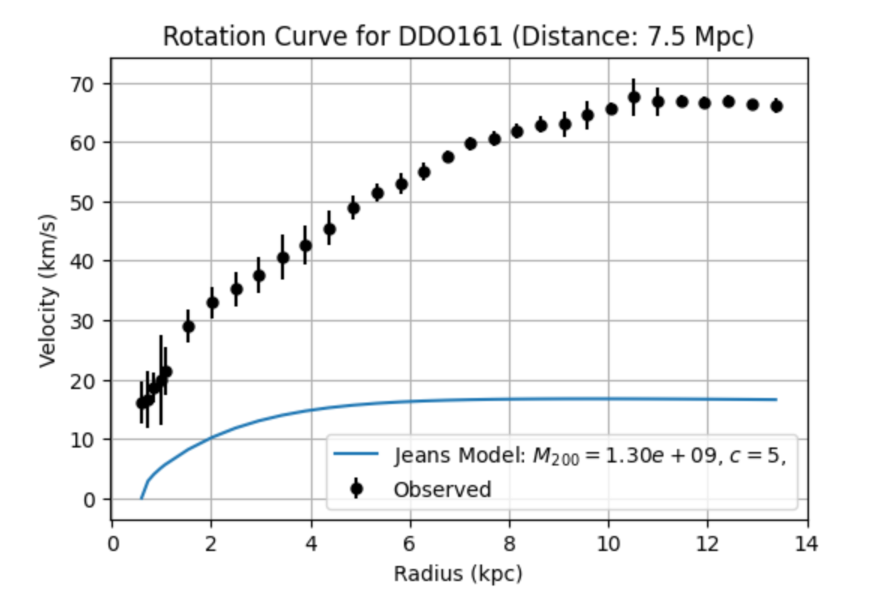

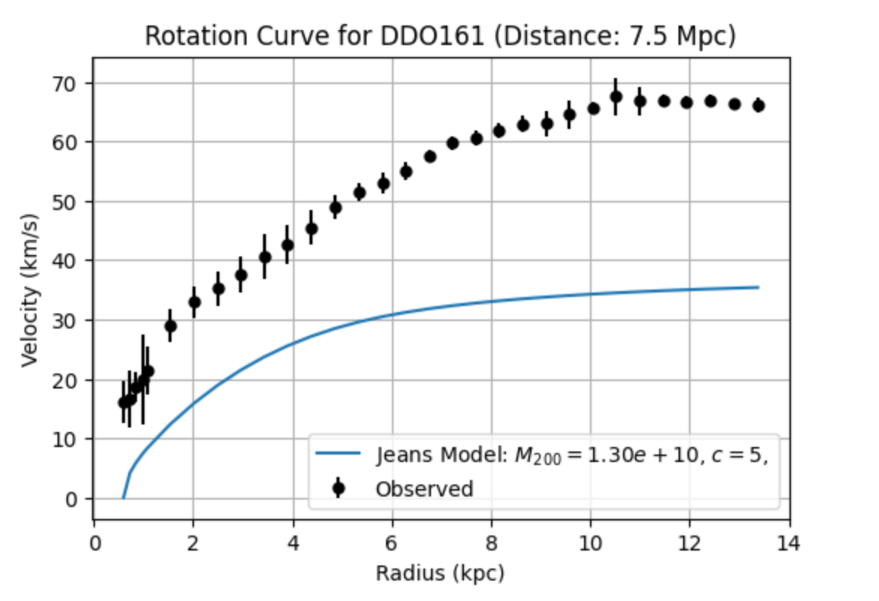

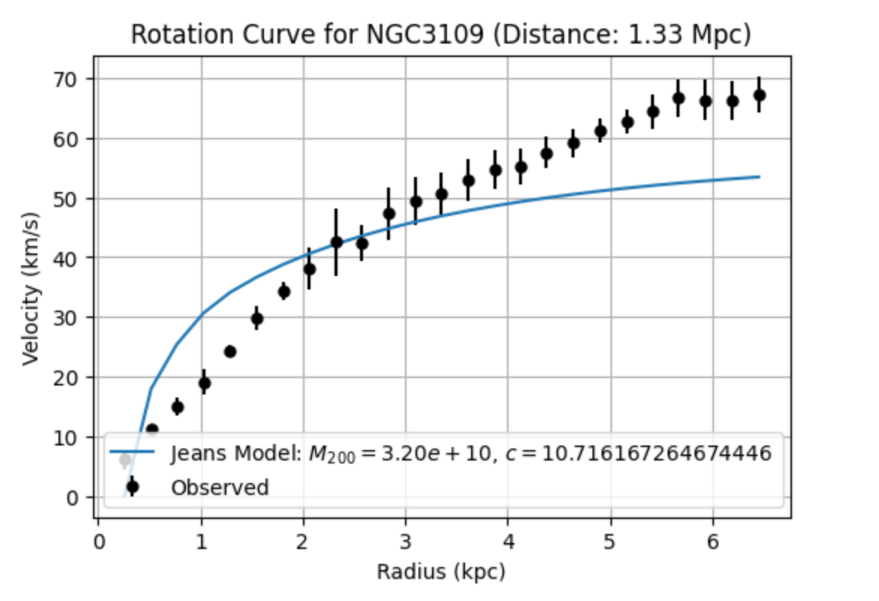

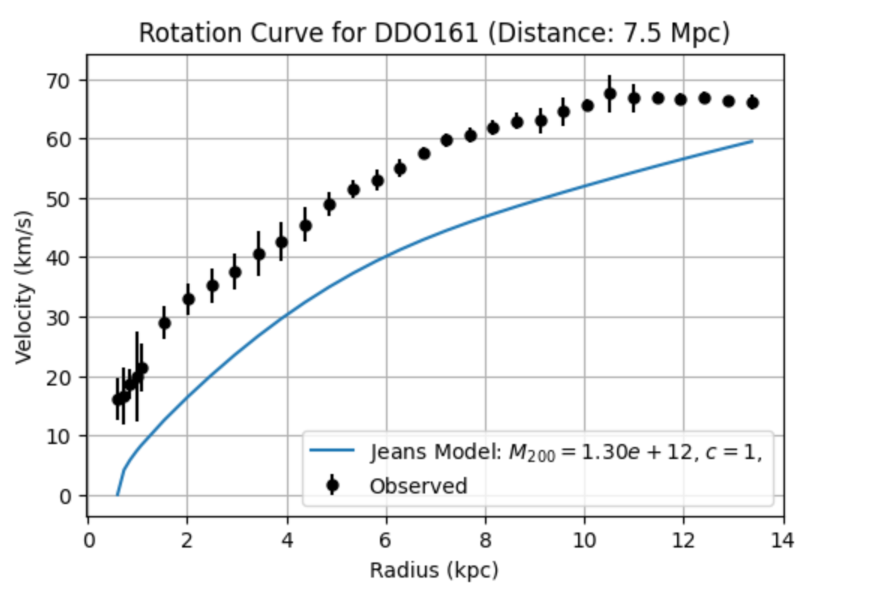

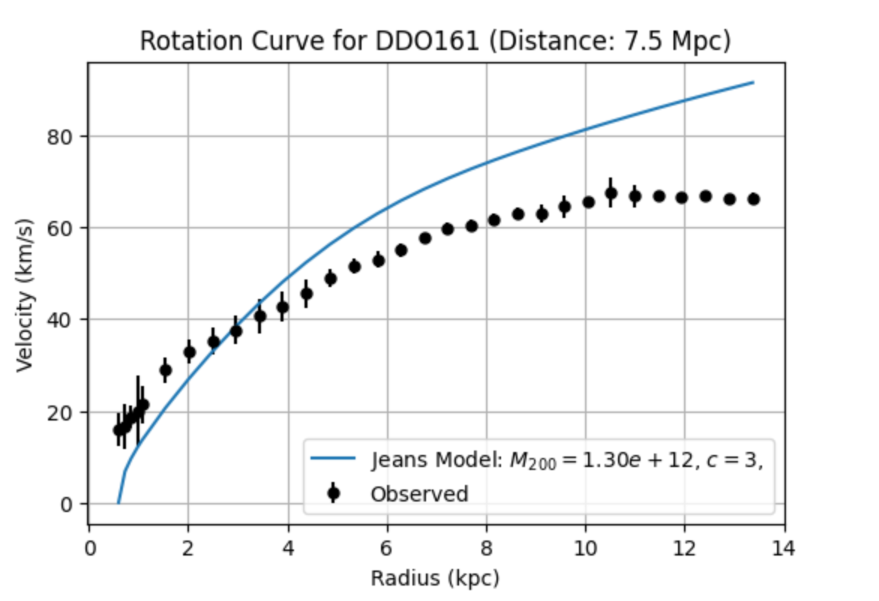

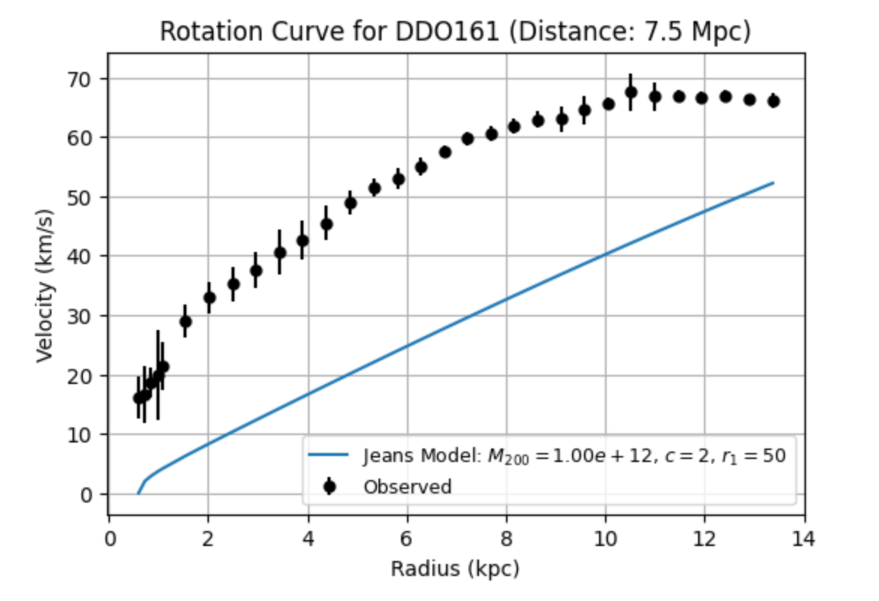

In [8]:
from IPython.display import Image, display

display(Image(filename="ScreenPics/2/Screen1.png", embed=True))
display(Image(filename="ScreenPics/2/Screen2.png", embed=True))
display(Image(filename="ScreenPics/2/Screen3.png", embed=True))
display(Image(filename="ScreenPics/2/Screen4.png", embed=True))
display(Image(filename="ScreenPics/2/Screen5.png", embed=True))
display(Image(filename="ScreenPics/2/Screen6.png", embed=True))

In [3]:
def check_criteria(df, distance):
    # Kriterium: Dataset >= 8
    if len(df) < 8:
        return False, "Too little Datapoints"

    # Kriterium: Flatregion 

    v_last = df['Vobs'].iloc[-3:].mean() 
    v_prev = df['Vobs'].iloc[-6:-3].mean()
    if abs(v_last - v_prev) / v_last > 0.2: # Fitvalue
        return False, "Not Flat enough"


     # Kriterium: No Bulge-Komponent 
    if 'Vbul' in df.columns and (df['Vbul'] > 0).any():
        return False, "Bulge Problem"
     

    return True, "OK"

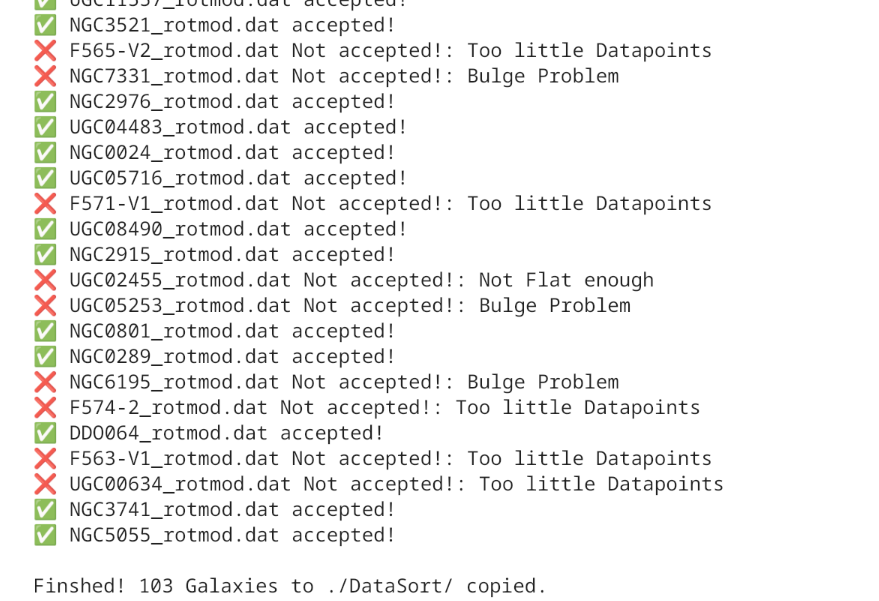

In [5]:
display(Image(filename="ScreenPics/2/ScreenData.png", embed=True))

In [7]:


# Probabillity funkction with stopfunctions (-infy) because not all values of M200 can be used
def log_prob(parameter, df, dist):
    M200 = parameter[0]
    if not (1e8 < M200 < 1e20): return -np.inf
    try:
        c = c_MCR(M200)
        profile = jeans.squashed(dist, M200, c)
        if profile is None: return -np.inf
        v_model = profile.V(df['Rad'], Lmax=0)
        if not np.all(np.isfinite(v_model)): return -np.inf
        chi2 = np.sum(((df['Vobs'] - v_model) / df['errV'])**2)
        return -0.5 * chi2
    except:
        return -np.inf

# Main
if __name__ == '__main__':
    df, units_info, dist = get_data(filename)

    # to get to less time test for Perfomance bacause it took too long to run
    print("Performance Test...")
    t_start = time.time()
    test_p = jeans.squashed(dist, 1e11, c_MCR(1e11))
    _ = test_p.V(df['Rad'], Lmax=0)
    t_single = time.time() - t_start
    print(f"Time for model: {t_single:.4f} s")
    
    #  Walkers with reduced speed
    ndim, nwalkers = 1, 16  # first is for how many parameters second is for parallel processing
    n_steps = 500           
    start_val = 8.0000e10 
    p0 = np.array([start_val]) * (1 + 1e-3 * np.random.randn(nwalkers, ndim)) # Vector where fluctuates around start value

    print(f"Duration (without Parallelprocessing): {(t_single * n_steps * nwalkers / 60):.2f} Minutes")

    # Run with paralelprocessing
    with Pool() as pool:
        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(df, dist), pool=pool)
        print("Start parallel MCMC... :)")
        sampler.run_mcmc(p0, n_steps, progress=True)

    # finish
    samples = sampler.get_chain(discard=100, flat=True) 
    # discards of the first 100 because the first is set value and some after are still fluctuations around this value
    mbereich = np.percentile(samples, 50)
# uses 50 % of Proberbillity to get the best mean value (my thought was because we have not many steps to be a bit generous with the sample)
    print(f"Best M200: {mbereich:.4e}")

NameError: name 'get_data' is not defined

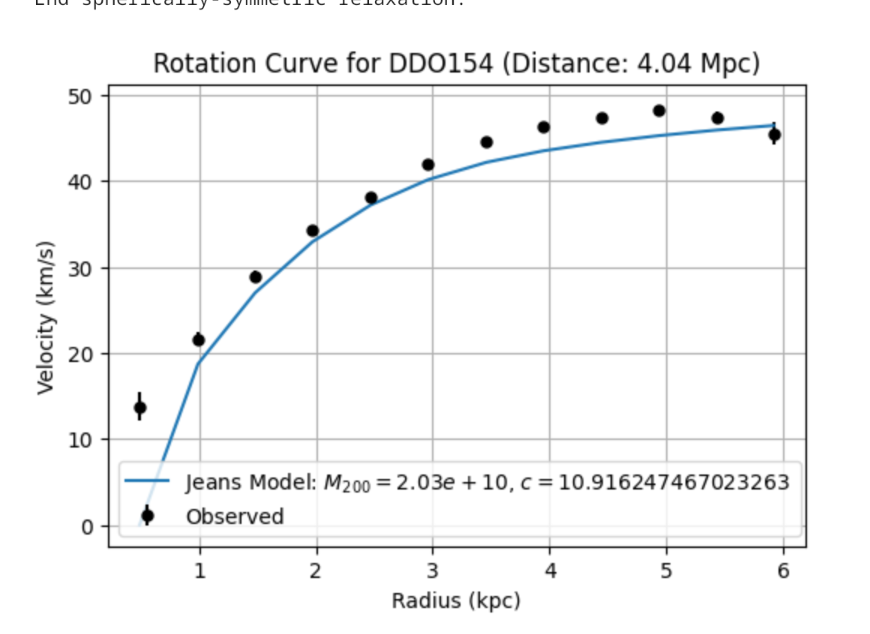

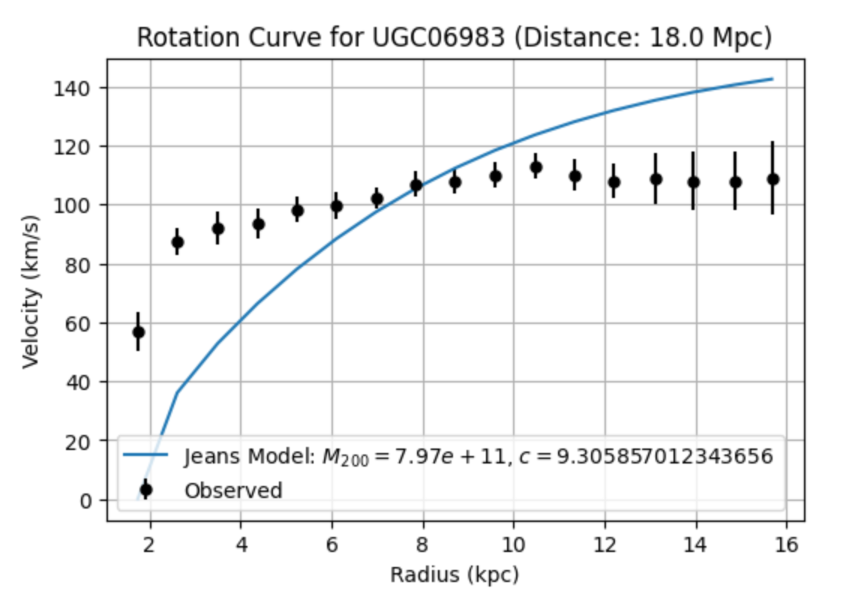

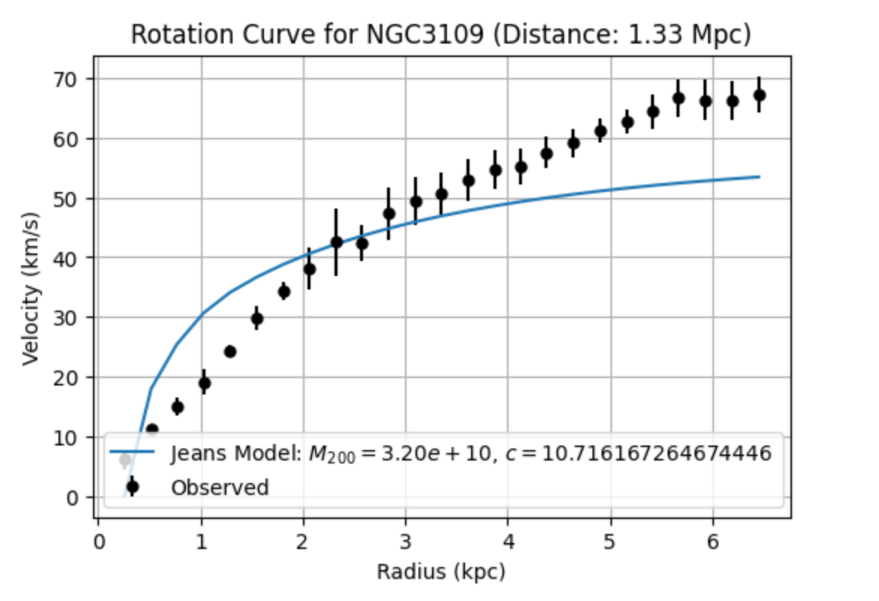

In [6]:
display(Image(filename="ScreenPics/2/ScreenFit1.png", embed=True))
display(Image(filename="ScreenPics/2/ScreenFit2.png", embed=True))
display(Image(filename="ScreenPics/2/ScreenFit3.png", embed=True))

# 2: What? (What happened?)
## Describe what happened during your activities for the week.

The initial testing phase for the various model variables was efficient. I performed manual fits for the concentration parameter $c$ and the virial mass $M_{200}$ across different galaxies. Subsequently, I implemented a given functional relation for $c(M_{200})$ based on the following model:

\begin{equation}
c = 10^{a + b \log_{10} \left( \frac{h\, M_{200}}{10^{12}} \right)} [3]
\end{equation}

where $a = 0.905$, $b = -0.101$, and $h = 0.7$. 

Following the guidelines in [2], a sample of galaxies was selected based on five specific criteria:


1. A minimum of 8 data points per galaxy.
2. Only galaxies with sufficient flatness were included. To quantify this, I analyzed the gradient using the last three and the preceding three data points (e.g., points 8, 7, 6 vs. 5, 4, 3) to constrain the profile. I used this method because there was no spesification given. 
3. The ratio of virial velocity to maximal observed velocity must satisfy: $\frac{V_{vir}}{V_{max}} \ge 1$.
4. Only bulgeless galaxies were considered.
5. These systems require a baryonic profile that aligns closely with the Hernquist model.

I applied selection criteria 1, 2, and 4.



To constrain the virial mass $M_{200}$, I implemented a Markov Chain Monte Carlo (MCMC) sampler using the emcee python package. The log-probability function was defined by incorporating a Gaussian likelihood based on the $\chi^2$ statistic:

\begin{equation}
\ln \mathcal{P} \propto -\frac{1}{2} \sum_{i} \left( \frac{V_{\mathrm{obs},i} - V_{\mathrm{model},i}}{\sigma_{V,i}} \right)^2
\end{equation}

To ensure physical consistency, a uniform prior was applied to $M_{200}$ within the range $[10^8, 10^{20}]\,M_\odot$. Any parameter sets yielding non-finite model velocities or falling outside this range were assigned a probability of $-\infty$.

Initial performance tests indicated a single model evaluation time of approximately $\texttt{t\_single}$ seconds. To optimize the total execution time, I utilized parallel processing by distributing 16 walkers across multiple CPU cores using a multiprocessing pool. The sampler was initialized with a small Gaussian ball around a starting value of $8.0 \times 10^{10}\,M_\odot$:

\begin{equation}
p_0 = M_{start} \cdot (1 + 10^{-3} \cdot \mathcal{R})
\end{equation}

where $\mathcal{R}$ represents a random normal distribution. This ensures that the walkers start in a closely grouped cluster within a high-probability region of the parameter space.

The simulation was run for 500 steps. To eliminate the bias of the initial starting positions, the first 100 steps were discarded as a "burn-in" phase. The final estimate for $M_{200}$ was determined using the $50^{th}$ percentile (median) of the flattened chain to obtain a robust "best-fit" value from the posterior distribution.

# 3: So what? (What does it mean?)
## Describe your results


By testing various parameters, the impact of each variable on the model became evident, as did the consequences of omitting them. I observed that excessively small values frequently triggered numerical errors. Consequently, I implemented boundary conditions and "stop functions" within the MCMC likelihood to prevent these errors from destabilizing the simulation. 

From the manual fitting process, a clear physical trend emerged: the mass parameter $M_{200}$ primarily dictates the amplitude (vertical scale) of the Jeans fit, whereas the radius parameter r governs the curvature of the profile. At large radii, the model exhibits nearly linear behavior.


Applying the initial three selection criteria significantly reduced the dataset by more than one-third, from approximately 175 to 103 galaxies. However, the second criterion (asympthotic flatness) introduces a degree of uncertainty. The current approximation works effectively for simple profiles but struggles with high scatter or datasets with a high density of points. While further refinement of this criterion is required, it currently serves as a necessary first step for data pre-filtering.


The current MCMC implementation is in a preliminary stage, as it produces a single optimized value rather than a full posterior simulation and currently considers only one free variable. The first plot shows the MCMC-derived model closely following the observed data points. For the purpose of testing a single parameter fit, I simplified the model by using the distance to the galaxy as the radius.



In the final two plots, a discrepancy remains that requires an adjustment of the radius. Based on the manual fits, there is a strong correlation between the model's accuracy and the r parameter. I conclude that refining the radius in future iterations will significantly improve the model's alignment with the observed velocity profiles.

# 4. Now what? (What's next?)
## Plan for the next week

I will collaborate with my research partner to further refine the exclusion criteria. The goal is to streamline the data filtering process and export the finalized galaxy sample as a structured list for further analysis.
    
I plan to incorporate additional physical variables into the MCMC simulation, for example the mass-to-light ratios or the radii. This will allow for a more nuanced investigation of the Jeans-model.
    
A key milestone will be the coupling of the current model with the baryonic potentials developed by the Potential-Group. This integration is currently pending the completion of the numerical integrals by the other team.

# 5. Bibliography

[1] Federico Lelli, Stacy S. McGaugh1 and James M. Schombert: SPARC: MASS MODELS FOR 175 DISK GALAXIES WITH
SPITZER PHOTOMETRY AND ACCURATE ROTATION CURVES.

[2] Zixiang Jia, Fangzhou Jiang, Shubo Li, Ran Li, Jing Wang, and Ling Zhu: An Enhanced Isothermal Jeans Approach to Constraining Dark Matter Self-Interactions from Galactic Kinematics

[3] Dutton & Maccio, 2014

An LLM was used to improve the readability and clarity of the text in English.

| Category       | Points      |
| ------------- |:------------:|
| Formatting    |       2 / 2       |
| Experience    |       1 / 2       |
| What?         |       2 / 2       |
| So what?      |       4 / 4       |
| Now what?     |       4 / 4       |
| Bibliography  |       3 / 3     |
| Style         |       3 / 3       |
| Total         |       19 / 20   |